In [1]:
!pip install -q yfinance 
!pip install -q PyPortfolioOpt
!pip install -q xgboost

In [55]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

import yfinance as yf

# plotting
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.patches as mpatches

from typing import Tuple
from utils import ForecastingMetrics, TradingMetrics
from backtest import Backtest

import warnings

# Finance 
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import plotting
import matplotlib.pyplot as plt
import pandas as pd
from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage
from statsmodels.tsa.api import VAR

# ml
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA

# Custom
from utils import PortfolioEvaluator
from backtest import Backtest

In [3]:
stocks = [
    # Tech
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA",
    # Finance
    "JPM", "BAC", "WFC", "C", "GS", "MS",
    # Consumer Goods
    "KO", "PG", "PEP", "WMT", "COST", "CL",
    # Energy
    "XOM", "CVX", "COP", "SLB", "EOG", "MPC",
    # ETF
    "SPY", "QQQ", "DIA", "IWM", "VTI"
]

# Define date range
start = "2022-01-01"
end = "2025-01-01"

# Download historical data
close_historical_df = yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"]
close_historical_df.head()

[*********************100%***********************]  30 of 30 completed


Ticker,AAPL,AMZN,BAC,C,CL,COP,COST,CVX,DIA,EOG,...,PEP,PG,QQQ,SLB,SPY,TSLA,VTI,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,178.270325,170.404495,41.931023,54.393005,76.912788,63.700039,540.298523,101.482430,341.583588,75.843269,...,154.084091,147.359787,392.184082,29.220688,453.210480,399.926666,230.069733,45.828438,45.858696,55.125225
2022-01-04,176.007782,167.522003,43.574486,54.815411,77.167397,66.463219,537.934082,103.328964,343.629242,79.329269,...,154.306808,147.875397,387.097351,30.639345,453.058624,383.196655,229.634140,47.653255,45.018562,57.198719
2022-01-05,171.325974,164.356995,42.839008,54.177509,77.485611,65.323395,524.291016,104.001198,340.098297,77.873306,...,154.832367,148.544815,375.205231,30.639345,444.358887,362.706665,224.653397,47.237705,45.627262,57.910122
2022-01-06,168.466003,163.253998,43.701607,55.953270,76.976425,67.775726,524.176636,104.886169,338.510468,79.470703,...,154.867996,147.296448,374.941559,31.367098,443.941376,354.899994,224.596603,48.448235,45.500454,59.272202
2022-01-07,168.632538,162.554001,44.654991,56.703205,76.776413,69.632240,511.191406,106.392326,338.435669,81.667130,...,155.063934,147.215057,370.879913,32.269894,442.186371,342.320007,223.573959,49.478085,45.934784,59.758049


From Figure 2, raw prices across the 30 stocks are highly variable and generally exhibit a strong upward trend. Thus, we applied a log transformation to stabilize the variance and allow for easier comparison across stocks.

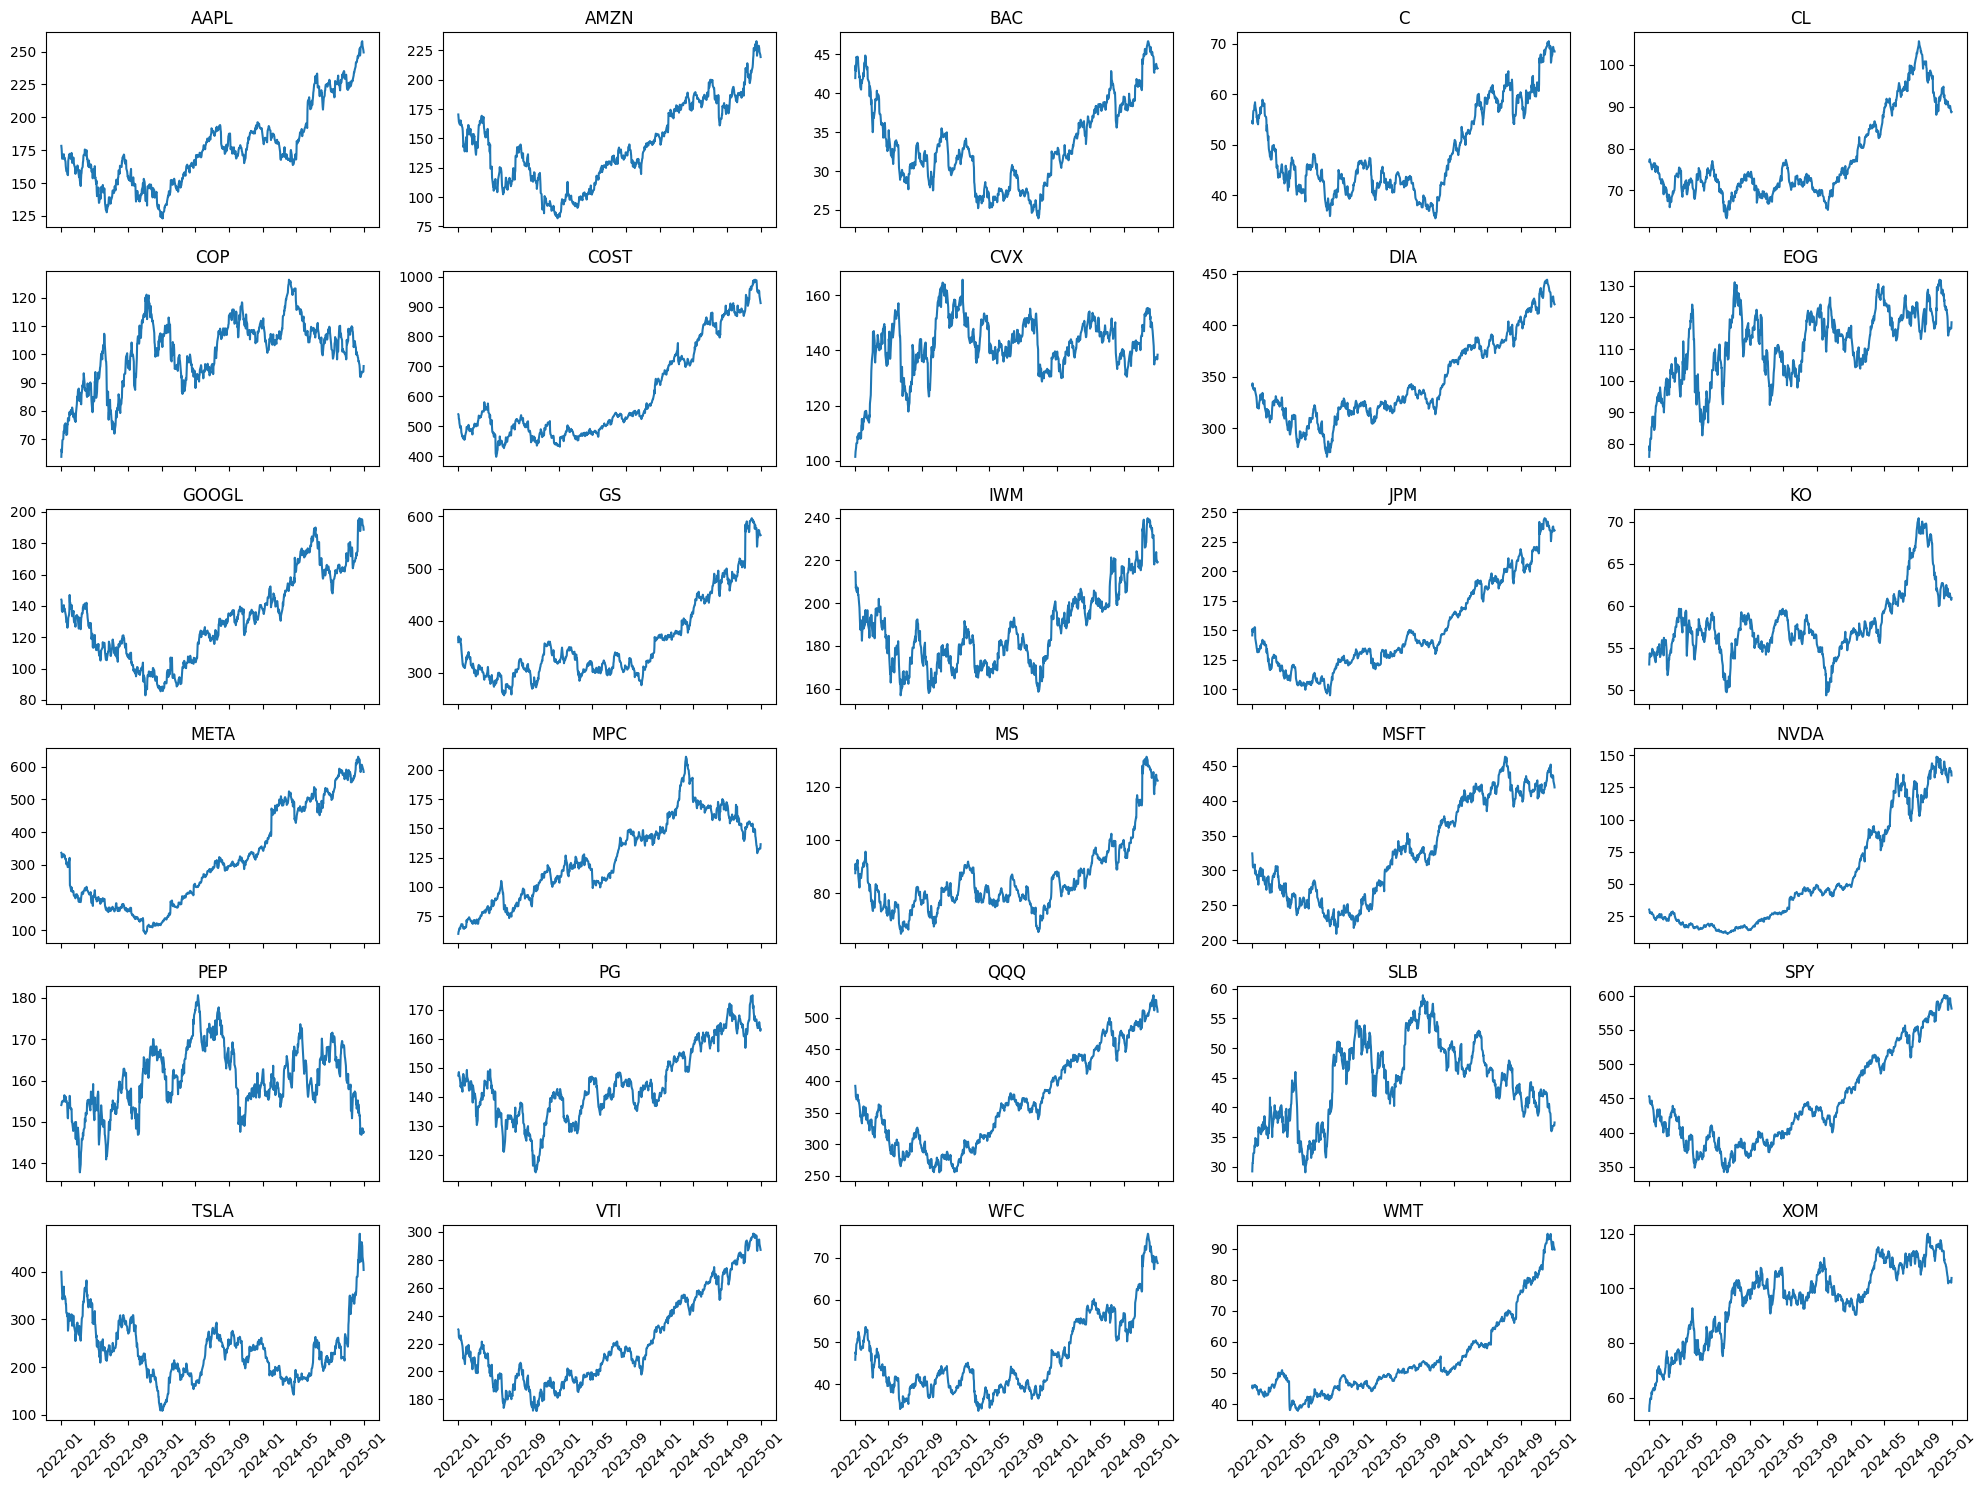

Figure 2. Prices of the 30 Stocks


In [4]:
fig, axs = plt.subplots(6, 5, figsize=(20, 15), sharex=True)

for ax, stock in zip(axs.flatten(), close_historical_df.columns):
    ax.plot(close_historical_df[stock])
    ax.set_title(stock)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Figure 2. Prices of the 30 Stocks")

# Markowitz

First, let us set up Markowitz Portfolio Theory. Let $r$ be a matrix of T historical daily log returns of n stocks:

$$
r =
\begin{bmatrix}
r_{t-1,1} & \cdots & r_{t-1,n} \\
\vdots & \ddots & \vdots \\
r_{t-T,1} & \cdots & r_{t-T,n}
\end{bmatrix},
$$

where:  
- $T$ is the number of days, so $T=752$  
- $n$ is number of stocks, so $n=30
- $r_{t,n}$ is the historical log return for the $n$-th stock for day $t$

For our case, $r$ is 
Then $\hat{\mu}$ is a vector of means of annualized expected log return:

$$
\hat{\mu} =
\begin{bmatrix}
\hat{\mu}_1 \\
\vdots \\
\hat{\mu}_n
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{T} \sum_{i=1}^{T} r_{t-i,1} \\
\vdots \\
\frac{1}{T} \sum_{i=1}^{T} r_{t-i,n}
\end{bmatrix},
$$

and $\hat{\Sigma}$ is the variance-covariance matrix of nnualized expected log return:

$$
\hat{\Sigma} =
\begin{bmatrix}
\hat{\sigma}_1^2 & \cdots & \hat{\sigma}_{1,n} \\
\vdots & \ddots & \vdots \\
\hat{\sigma}_{1,n} & \cdots & \hat{\sigma}_n^2
\end{bmatrix},
$$

where $\hat{\sigma}_i^2$ is the empirical variance of historical log returns of the $i$-th stock and $\hat{\sigma}_{i,j}$ is the empirical covariance between historical log returns of the $i$-th and $j$-th stock.  

  Stock   Weight
0   WMT  0.56538
1  NVDA  0.14750
2   MPC  0.14690
3   XOM  0.14021

Expected annual return: 25.3%
Annual volatility: 18.2%
Sharpe Ratio: 1.28


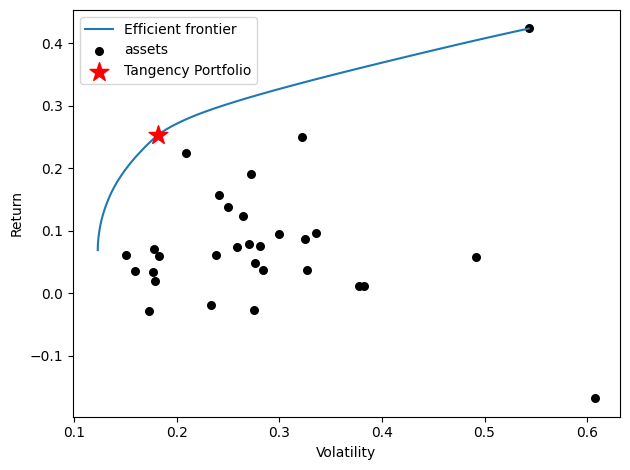

In [5]:
# mu and Sigma are annualized
mu = mean_historical_return(close_historical_df, log_returns=True)
Sigma = CovarianceShrinkage(close_historical_df, log_returns=True).ledoit_wolf()

# Compute tangency portfolio
ef_tan = EfficientFrontier(mu, Sigma)
tangency_portfolio = ef_tan.max_sharpe(risk_free_rate=0.02)
weights_df = pd.DataFrame(
    [(stock, weight) for stock, weight in ef_tan.clean_weights().items() if weight > 0],
    columns=['Stock', 'Weight']
).sort_values(by='Weight', ascending=False).reset_index(drop=True)

print(weights_df)
print()
exp_return, vol, sharpe = ef_tan.portfolio_performance(verbose=True, risk_free_rate=0.02)



# Create another EF instance just for plotting
ef_plot = EfficientFrontier(mu, Sigma)
plotting.plot_efficient_frontier(ef_plot, show_assets=True)
plt.scatter(vol, exp_return, marker="*", color="r", s=200, label="Tangency Portfolio", zorder=10)
plt.legend()
plt.show()

In [6]:
# Keep only the stocks with non-zero weights
selected_stocks = ["WMT", "NVDA", "MPC", "XOM"]
close_historical_df = close_historical_df[selected_stocks]

In [7]:
close_historical_df.shape

(753, 4)

# Baselines

To construct the baseline models (mean, naive, and seasonal naive) in a single figure, we first assessed whether seasonality was present across the stocks. As shown in Figure 3, there is no consistent or systematic seasonal pattern observable across the full set of assets. Given this inconsistency, we proceed by assuming a simplified seasonality of five business days (a week) for the baseline seasonal naive model.

We also implement a three-way data split consisting of training, validation, and test sets. The training and validation sets cover the period from January 2022 to January 2025, using an 80–20 split. The test set consists of the random 60-day period of observations consisting after January 2025.

Figure 3. ACF of the 4 Stocks


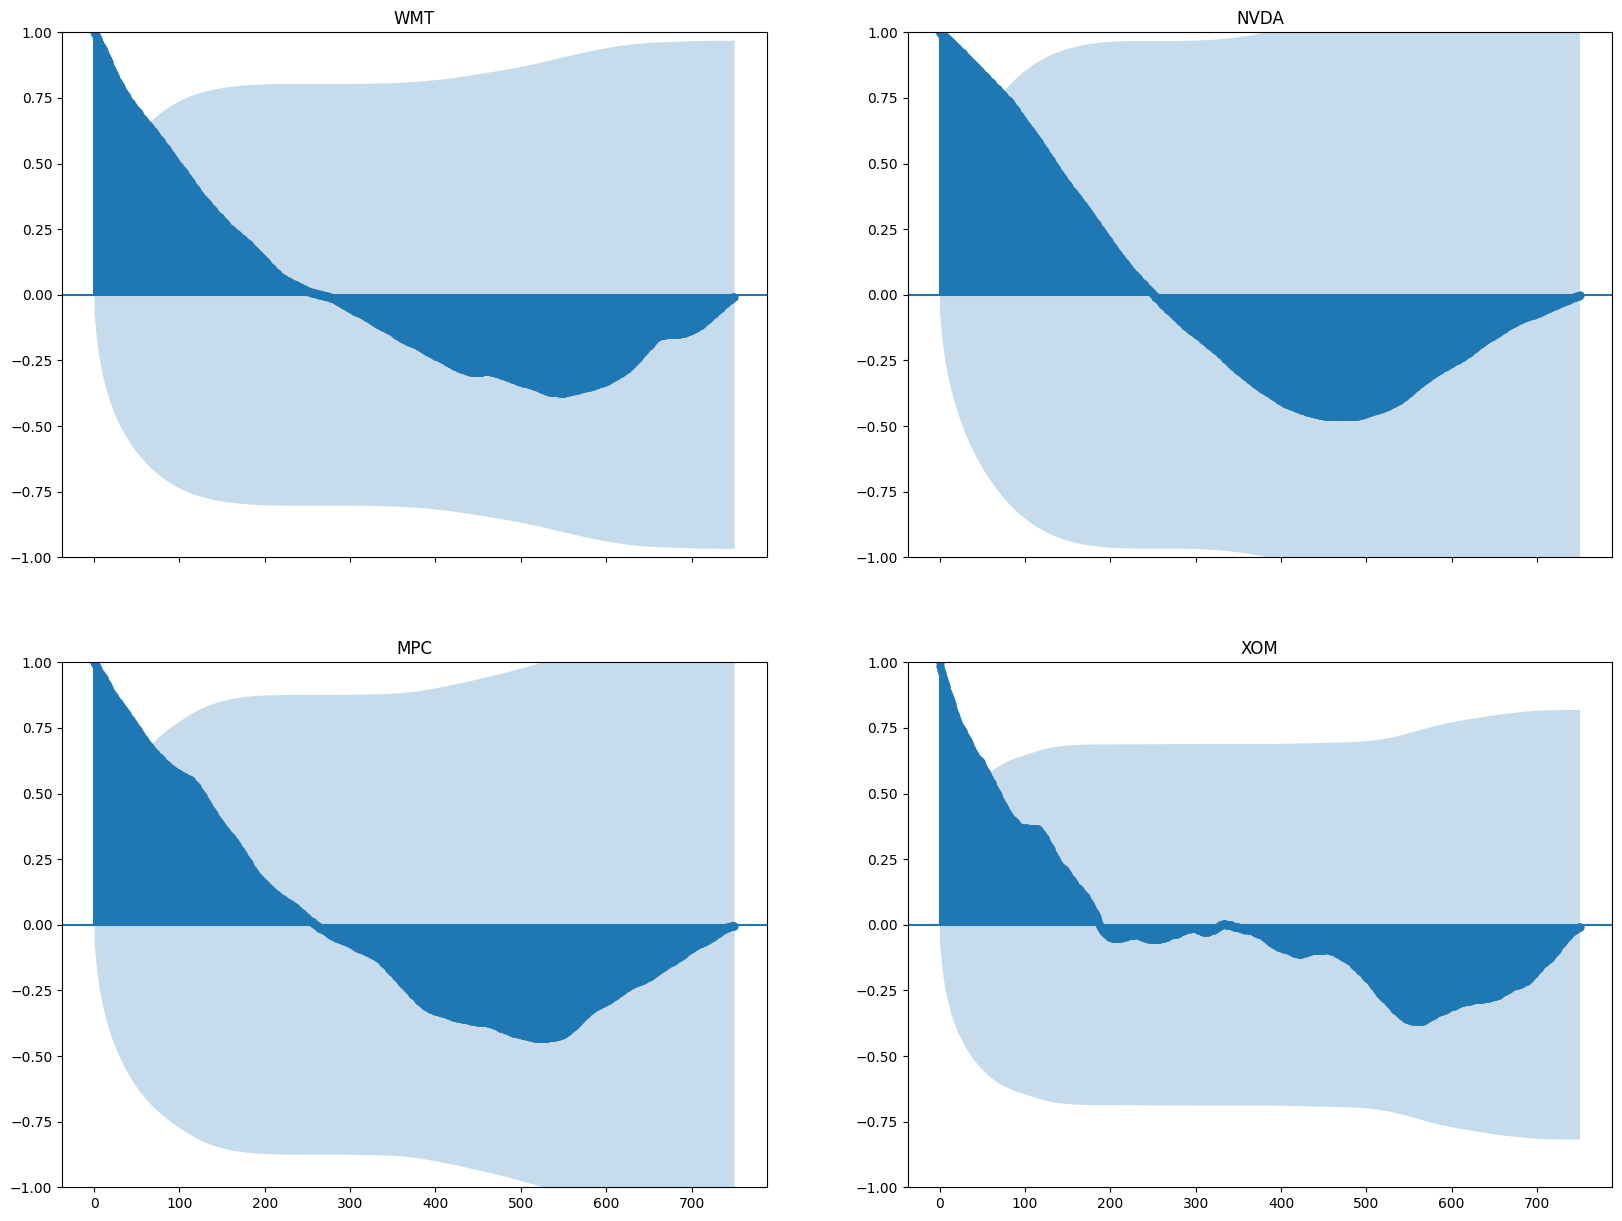

In [8]:
# Apply log
close_log_df = np.log(close_historical_df)

fig, axs = plt.subplots(2, 2, figsize=(20, 15), sharex=True)

for ax, stock in zip(axs.flatten(), close_log_df.columns):
    plot_acf(close_log_df[stock], ax=ax, lags=750, title=stock)

print("Figure 3. ACF of the 4 Stocks")

In [9]:
# Total number of rows
n = close_log_df.shape[0]

# Compute split points
train_end = int(n * 0.7)           # 70% for training
val_end = train_end + int(n * 0.2) # next 20% for validation

# Create splits
train_df = close_log_df.iloc[:train_end]
val_df = close_log_df.iloc[train_end:val_end]
test_df = close_log_df.iloc[val_end:]

print(f"Training set: {train_df.shape[0]} rows ({train_df.shape[0]/n:.0%})")
print(f"Validation set: {val_df.shape[0]} rows ({val_df.shape[0]/n:.0%})")
print(f"Test set: {test_df.shape[0]} rows ({test_df.shape[0]/n:.0%})")


Training set: 527 rows (70%)
Validation set: 150 rows (20%)
Test set: 76 rows (10%)


In [10]:
def forecast_seasonal_naive(df: pd.DataFrame, m: int = 5, horizon: int = None) -> pd.DataFrame:
    """
    Seasonal naïve forecasting model applied column-wise to a DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame where each column represents a univariate time series
        (e.g., multiple stock price series).
    m : int, optional (default=5)
        The assumed seasonality length. The model uses the last `m` observations
        of each column as the repeating seasonal pattern.
    horizon : int, optional
        Number of future time steps to forecast. If None, uses length of df.

    Returns
    -------
    pd.DataFrame
        A DataFrame containing seasonal naïve forecasts for each column of `df`.
        Each column contains `horizon` forecasts derived from the last `m` values.
    """
    if horizon is None:
        horizon = len(df)

    forecasts = {}
    for col in df.columns:
        last_m_vals = df[col].iloc[-m:].values.ravel()
        repeated_vals = np.tile(last_m_vals, horizon)[:horizon]
        forecasts[col] = repeated_vals

    return pd.DataFrame(forecasts)


In [11]:
horizon = val_df.shape[0]  # number of rows to forecast

# Mean forecast
mean_forecast = pd.DataFrame([train_df.mean().values] * horizon,
                             index=val_df.index,
                             columns=val_df.columns)

# Naive forecast (last value)
naive_forecast = pd.DataFrame([train_df.iloc[-1].values] * horizon,
                              index=val_df.index,
                              columns=val_df.columns)

# Seasonal naive forecast
seasonal_naive_forecast = forecast_seasonal_naive(train_df, m=20, horizon=horizon)
seasonal_naive_forecast.index = val_df.index


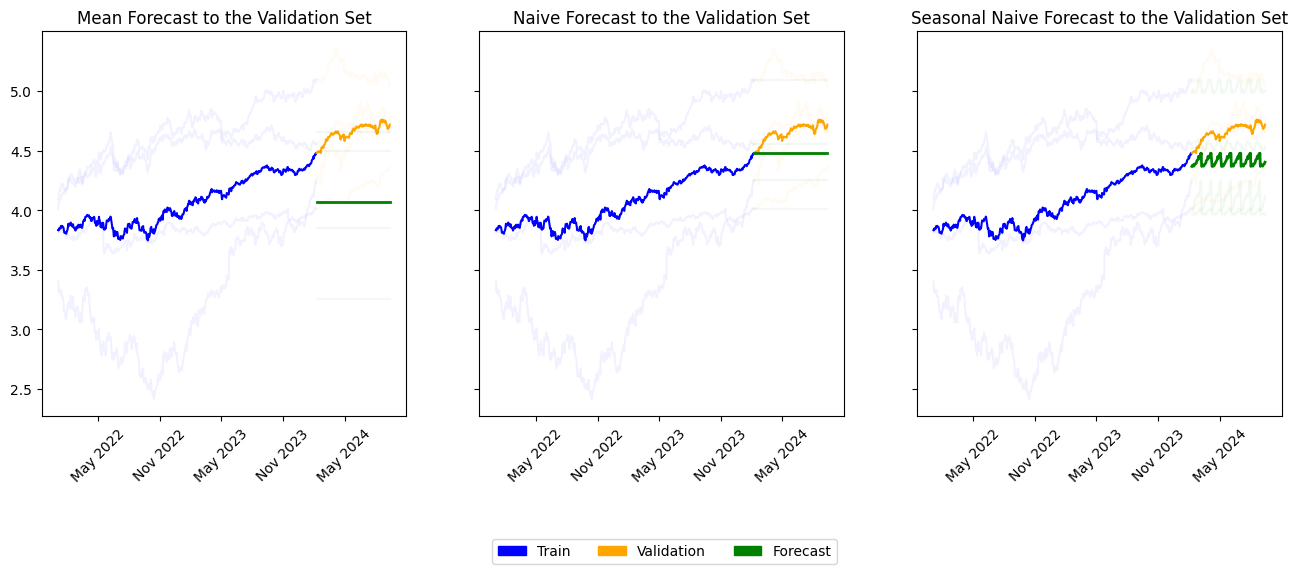

In [12]:

# Drawing time!
fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

opacity_num = 0.05
for ax in axs:
    ax.plot(train_df, color='blue', alpha=opacity_num)
    ax.plot(train_df.mean(axis=1), color='blue')

    ax.plot(val_df, color='orange', alpha=opacity_num)
    ax.plot(val_df.mean(axis=1), color='orange', label='Val Median')

# Plot the mean
axs[0].plot(mean_forecast, label='Mean Forecast', color='green', alpha=opacity_num)
axs[0].plot(mean_forecast.mean(axis=1), label='Mean Forecast', linewidth=2, color='green')
axs[0].set_title('Mean Forecast to the Validation Set')

# plot the naive
axs[1].plot(naive_forecast, label='Naive Forecast', color='green', alpha=opacity_num)
axs[1].plot(naive_forecast.mean(axis=1), label='Naive Forecast', linewidth=2, color='green')
axs[1].set_title('Naive Forecast to the Validation Set')

# plot the Seasonal Naive
axs[2].plot(seasonal_naive_forecast, label='Seasonal Naive Forecast', color='green', alpha=opacity_num)
axs[2].plot(seasonal_naive_forecast.mean(axis=1), label='Seasonal Naive Forecast', linewidth=2, color='green')
axs[2].set_title('Seasonal Naive Forecast to the Validation Set')

# Prettier x-axis
for ax in axs:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # major ticks each month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # format as 'Jan 2025'
    ax.tick_params(axis='x', rotation=45)  # rotate labels

# Add patches legend at the bottom for dataset colors
train_patch = mpatches.Patch(color='blue', label='Train')
val_patch = mpatches.Patch(color='orange', label='Validation')
forecast_patch = mpatches.Patch(color='green', label='Forecast')

plt.legend(handles=[train_patch, val_patch, forecast_patch], loc='best', bbox_to_anchor=(-0.2, -0.3), ncol=3)



plt.show()


In [13]:
# Dictionary to store all metrics
performance_stock = {}

for stock in val_df.columns:
    # Compute metrics for each baseline
    performance_stock[stock] = {
        'Mean': ForecastingMetrics.compute_all_metrics(val_df[stock], mean_forecast[stock]),
        'Naive': ForecastingMetrics.compute_all_metrics(val_df[stock], naive_forecast[stock]),
        'Seasonal Naive': ForecastingMetrics.compute_all_metrics(val_df[stock], seasonal_naive_forecast[stock])
    }

In [14]:
def performance_dict_to_df(performance_stock_dict):
    """
    Converts a nested dictionary of performance metrics into a multi-index DataFrame.
    
    Parameters
    ----------
    performance_stock_dict : dict
        Nested dict of the form {stock: {model_name: {metric_name: value, ...}, ...}, ...}
    
    Returns
    -------
    pd.DataFrame
        MultiIndex DataFrame with index ['Stock', 'Model'] and metric columns.
    """
    df_list = []

    for stock, metrics_per_model in performance_stock_dict.items():
        for model, metrics in metrics_per_model.items():
            row = metrics.copy()
            row['Stock'] = stock
            row['Model'] = model
            df_list.append(row)
    
    metrics_df = pd.DataFrame(df_list).set_index(['Stock', 'Model'])
    return metrics_df

performance_dict_to_df(performance_stock)


MAE       MSE      RMSE       MAPE      SMAPE  \
Stock Model                                                                
WMT   Mean            0.309011  0.104154  0.322728   7.382479   7.689179   
      Naive           0.145786  0.029891  0.172891   3.456762   3.541766   
      Seasonal Naive  0.177148  0.040336  0.200838   4.211177   4.326818   
NVDA  Mean            1.355541  1.871434  1.368004  29.260727  34.340237   
      Naive           0.366027  0.167392  0.409136   7.785086   8.176199   
      Seasonal Naive  0.511087  0.297947  0.545845  10.938992  11.655951   
MPC   Mean            0.491423  0.246697  0.496686   9.522042  10.007131   
      Naive           0.066385  0.008824  0.093936   1.271640   1.287488   
      Seasonal Naive  0.123777  0.021508  0.146655   2.385126   2.425303   
XOM   Mean            0.184296  0.036134  0.190090   3.927441   4.011040   
      Naive           0.123646  0.017429  0.132018   2.631739   2.671726   
      Seasonal Naive  0.144165  0.023349  0.152804   3.070590   3.124379   

                      Directional Accuracy  
Stock Model                                 
WMT   Mean                       42.953022  
      Naive                      42.953022  
      Seasonal Naive             48.993290  
NVDA  Mean                       45.637585  
      Naive                      45.637585  
      Seasonal Naive             47.651009  
MPC   Mean                       46.308723  
      Naive                      46.308723  
      Seasonal Naive             48.993290  
XOM   Mean                       48.322147  
      Naive                      48.322147  
      Seasonal Naive             50.335571

# ARIMA


First thing to consider when creating an ARIMA model is testing the data for stationarity using the Augmented Dickey-Fuller (ADF) and Kwiatkowski-Phillips-Schmidt-Shin test.

In [17]:
warnings.filterwarnings("ignore")

# --- ADF Test Function ---
def adf_test_suite(timeseries):
    """
    Performs the Augmented Dickey-Fuller test on a time series.
    H0: The series is non-stationary.
    """
    # Use 'ct' for constant and trend since visual inspection (Figure 2) shows a clear trend
    result = adfuller(timeseries, autolag='AIC', regression='ct')
    
    p_value = result[1]
    
    # Check p-value against a 5% significance level (alpha=0.05)
    is_stationary = 'Stationary' if p_value <= 0.05 else 'Non-Stationary'
    
    return pd.Series({
        'ADF Statistic': result[0],
        'ADF P-value': p_value,
        'ADF Lags Used': result[2],
        'ADF Conclusion (alpha=0.05)': is_stationary
    })

# --- KPSS Test Function ---
def kpss_test_suite(timeseries):
    """
    Performs the Kwiatkowski-Phillips-Schmidt-Shin test on a time series.
    H0: The series is trend-stationary.
    """
    # Use 'ct' for trend-stationarity (constant and trend)
    result = kpss(timeseries, regression='ct', nlags='auto')
    
    p_value = result[1]
    
    # Check p-value against a 5% significance level (alpha=0.05)
    is_stationary = 'Stationary' if p_value > 0.05 else 'Non-Stationary'
    
    return pd.Series({
        'KPSS Statistic': result[0],
        'KPSS P-value': p_value,
        'KPSS Lags Used': result[2],
        'KPSS Conclusion (alpha=0.05)': is_stationary
    })

In [18]:
# Difference only once
close_log_df1 = close_log_df.diff().dropna()

adf_results_df = close_log_df1.apply(adf_test_suite, axis=0).T
kpss_results_df = close_log_df1.apply(kpss_test_suite, axis=0).T

final_results = pd.DataFrame({
    'ADF Conclusion': adf_results_df['ADF Conclusion (alpha=0.05)'],
    'KPSS Conclusion': kpss_results_df['KPSS Conclusion (alpha=0.05)']
})

def consolidate_conclusion(row):
    adf_c = row['ADF Conclusion']
    kpss_c = row['KPSS Conclusion']
    
    if adf_c == 'Stationary' and kpss_c == 'Stationary':
        return 'Strictly Stationary (Strong Evidence)'
    elif adf_c == 'Non-Stationary' and kpss_c == 'Non-Stationary':
        return 'Non-Stationary (Strong Evidence)'
    elif adf_c == 'Stationary' and kpss_c == 'Non-Stationary':
        # ADF rejects Unit Root, KPSS rejects Trend-Stationary. Contradictory.
        # Often implies the series is difference stationary (needs differencing).
        return 'Difference Stationary (Requires Differencing)'
    elif adf_c == 'Non-Stationary' and kpss_c == 'Stationary':
        # ADF fails to reject Unit Root, KPSS fails to reject Trend-Stationary.
        # Often implies the series is trend stationary (needs detrending).
        return 'Trend Stationary (Requires Detrending)'
    else:
        return 'Inconclusive/Contradictory'

final_results['Consolidated Conclusion'] = final_results.apply(consolidate_conclusion, axis=1)
final_results

,ADF Conclusion,KPSS Conclusion,Consolidated Conclusion
Ticker,,,
WMT,Stationary,Stationary,Strictly Stationary (Strong Evidence)
NVDA,Stationary,Non-Stationary,Difference Stationary (Requires Differencing)
MPC,Stationary,Stationary,Strictly Stationary (Strong Evidence)
XOM,Stationary,Stationary,Strictly Stationary (Strong Evidence)


We can see that NVDA and META may still need differencing, but we can check by graphing them first.

Ticker        NVDA
count   752.000000
mean      0.001990
std       0.034430
min      -0.105412
25%      -0.018763
50%       0.003264
75%       0.021791
max       0.218088
Ticker
NVDA    0
dtype: int64


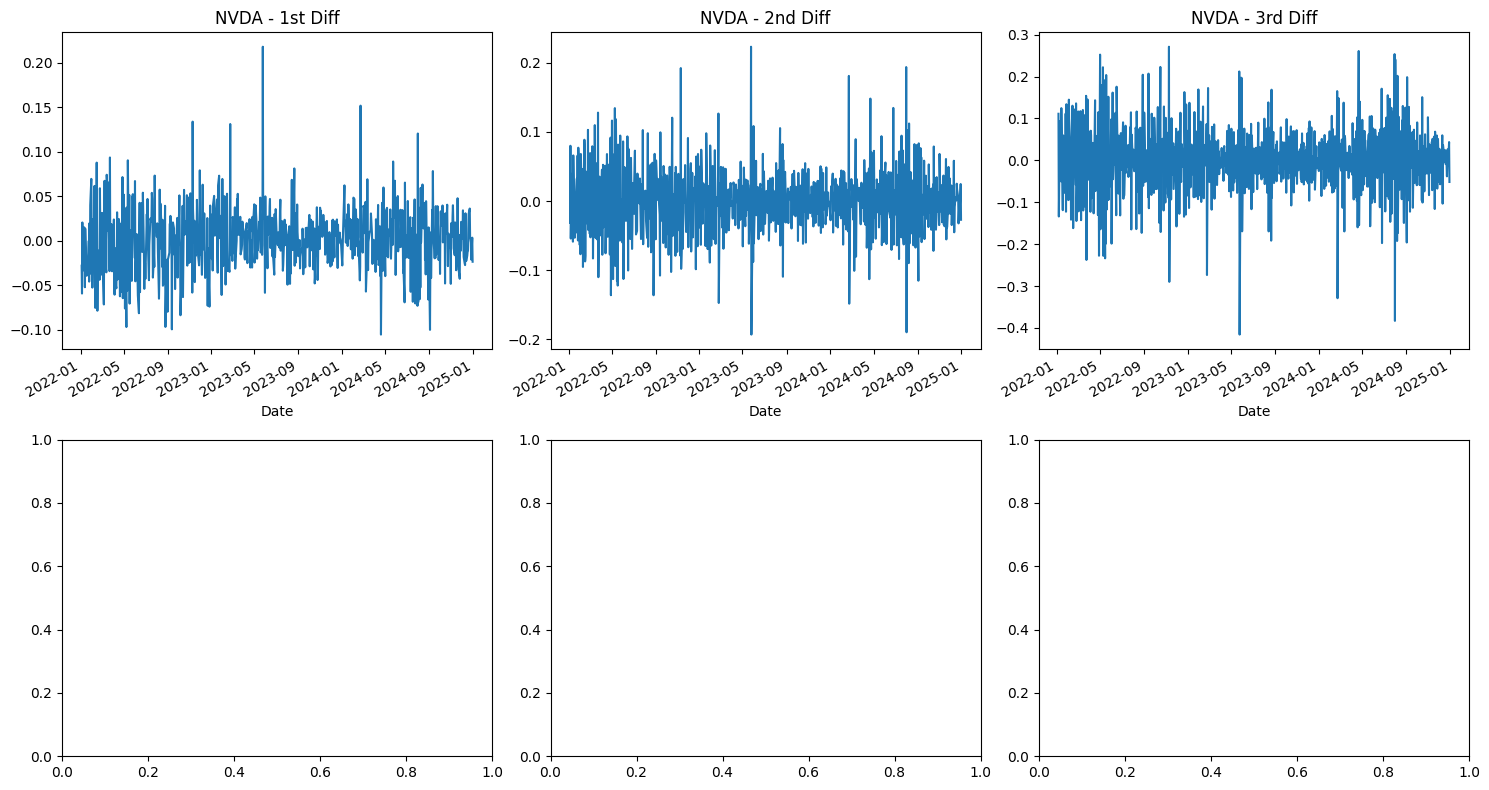

In [19]:
# Check META and NVDA data quality
print(close_log_df1[['NVDA']].describe())
print(close_log_df1[['NVDA']].isnull().sum())

# Plot the differenced series
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, stock in enumerate(['NVDA']):
    # Original log returns
    close_log_df1[stock].plot(ax=axes[i, 0], title=f'{stock} - 1st Diff')
    # 2nd difference
    close_log_df1[stock].diff().plot(ax=axes[i, 1], title=f'{stock} - 2nd Diff')
    # 3rd difference
    close_log_df1[stock].diff().diff().plot(ax=axes[i, 2], title=f'{stock} - 3rd Diff')
plt.tight_layout()
plt.show()

Visually, the 1st order difference already looks stationary. There is also prevalent financial theory that log returns (1st difference in log price) is standard, overdifferencing may cause issues with noise.

Optimal d = 1

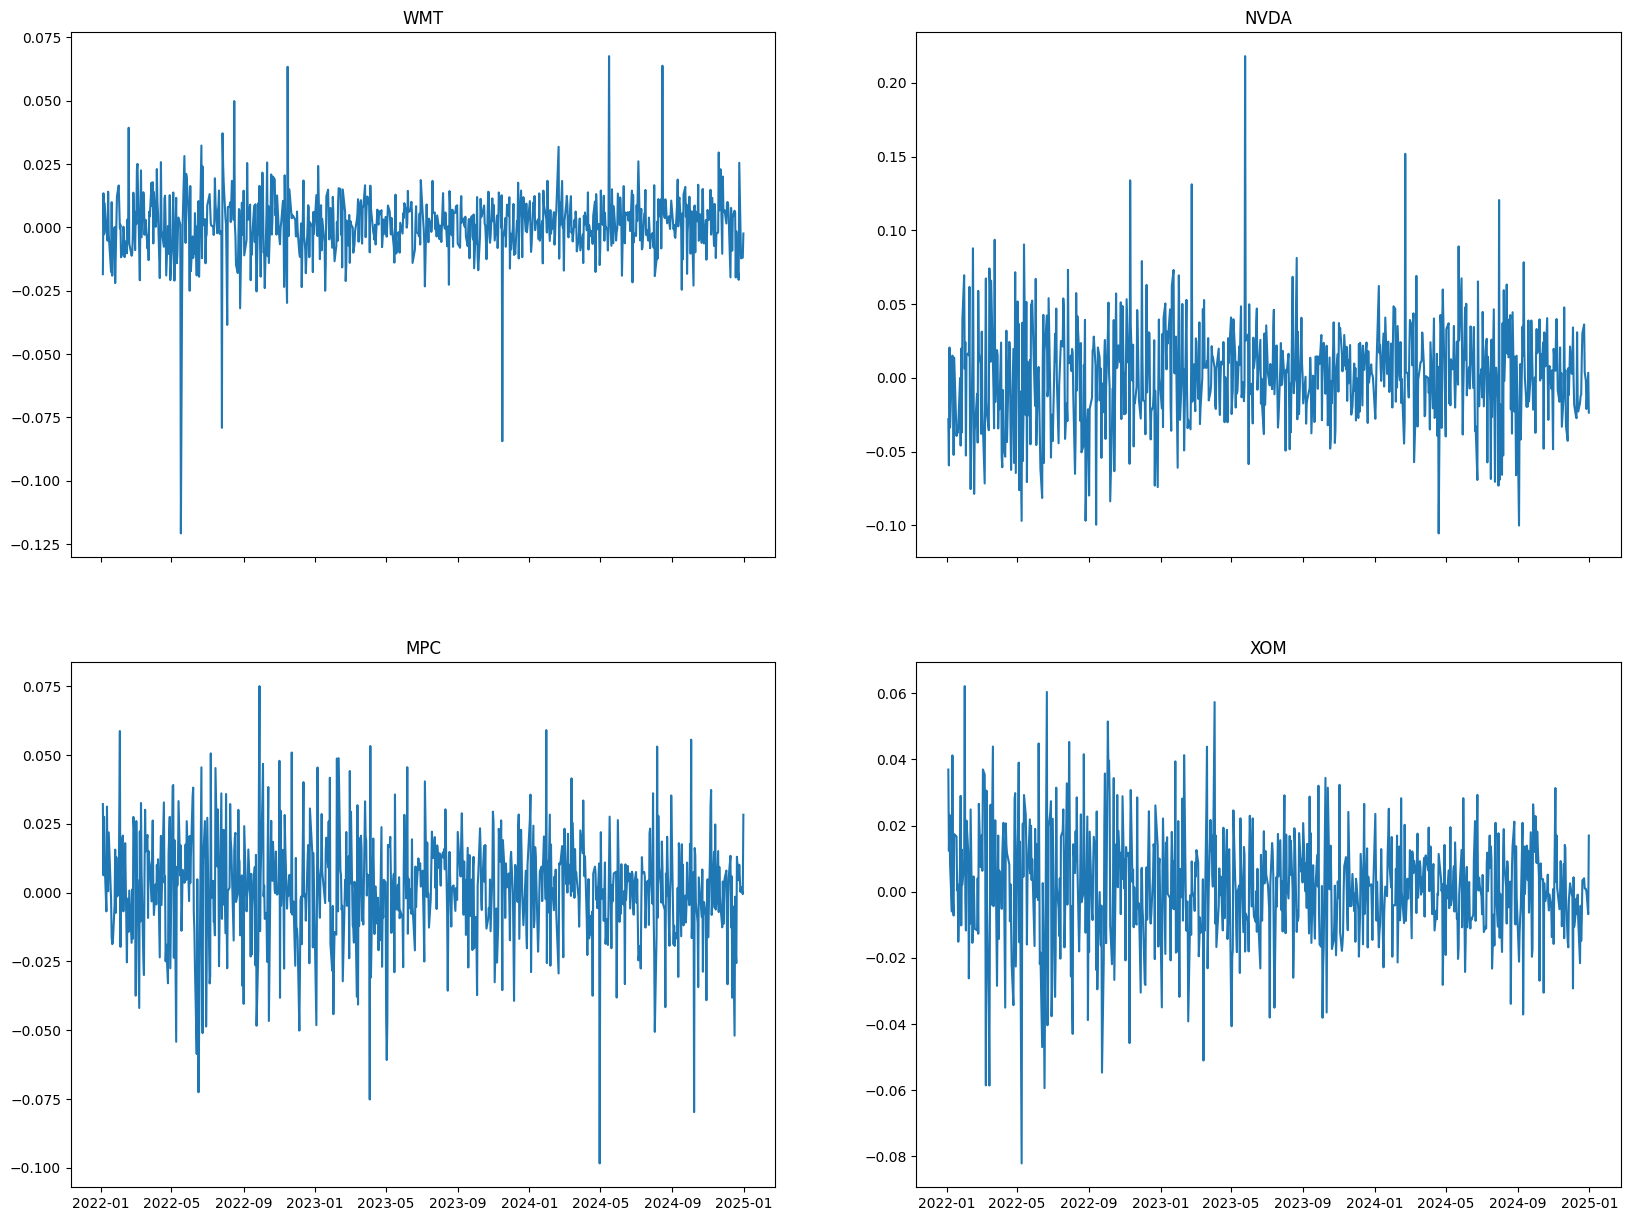

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(20, 15), sharex=True)

for ax, stock in zip(axs.flatten(), close_log_df1.columns):
    ax.plot(close_log_df1[stock], label=stock)
    ax.set_title(stock)



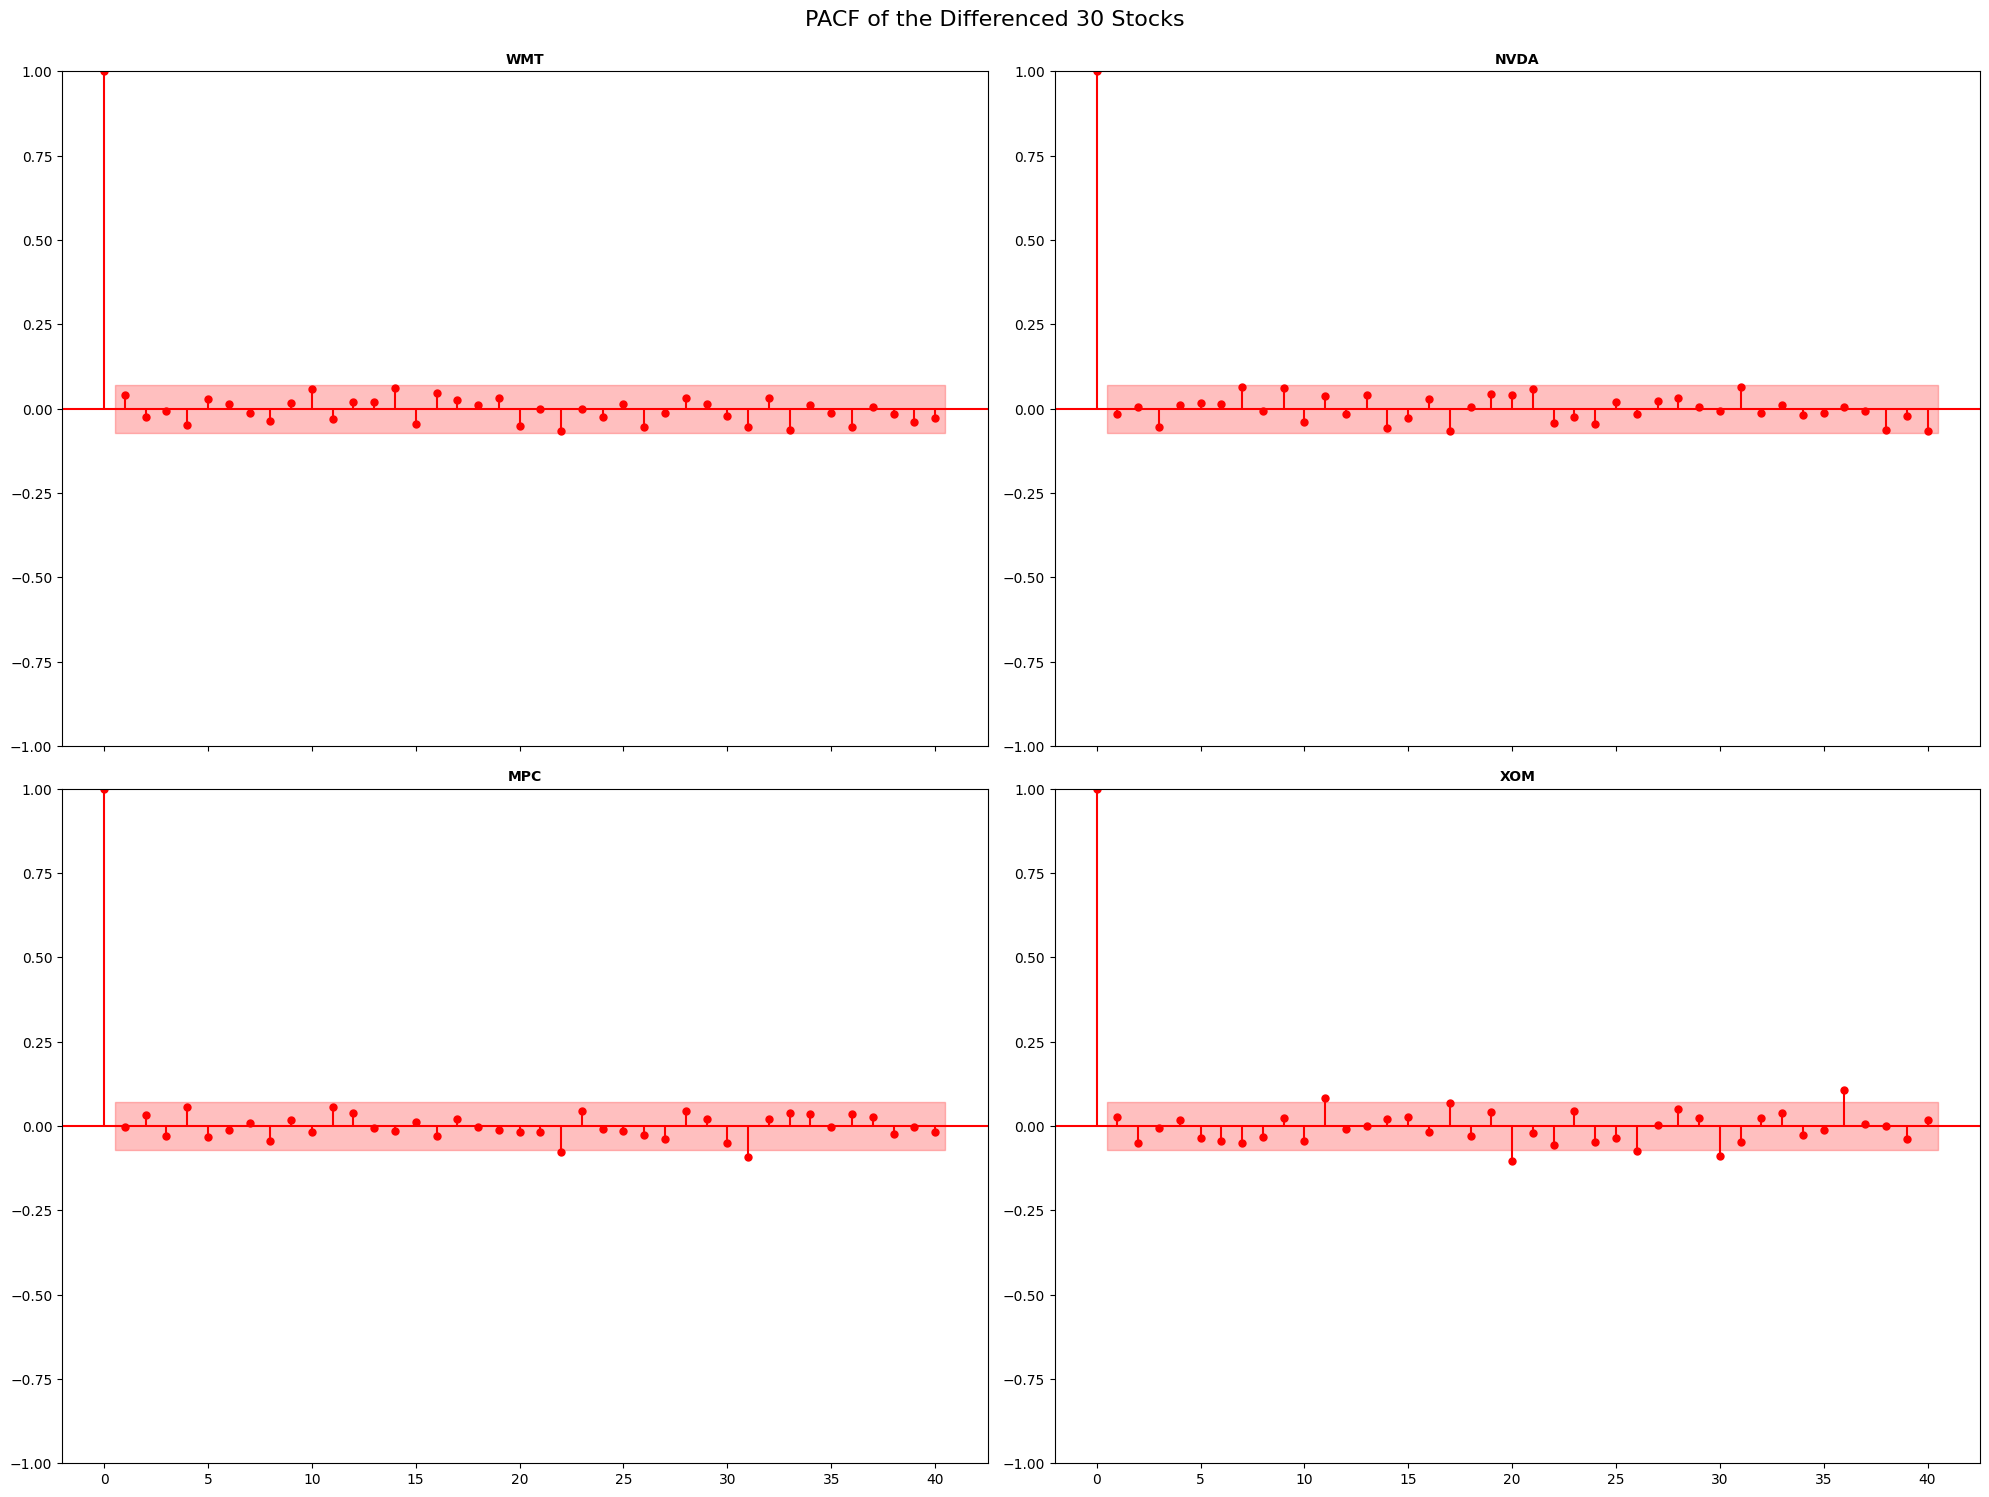

Figure: PACF of the differenced 30 Stocks


In [21]:
# Assuming close_log_df1 is your differenced data
fig, axs = plt.subplots(2, 2, figsize=(20, 15), sharex=True)

for ax, stock in zip(axs.flatten(), close_log_df1.columns):
    # Plot PACF
    plot_pacf(close_log_df1[stock].dropna(), ax=ax, lags=40, method='ywm')
    ax.set_title(stock, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    #ax.set_ylim(-0.15, 0.15)
    for item in ax.collections:
        item.set_color('red')
    for item in ax.lines:
        item.set_color('red')


# Add main title
fig.suptitle('PACF of the Differenced 30 Stocks', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

print("Figure: PACF of the differenced 30 Stocks")

All of the stocks don't seem to show much autocorrelation after differencing, so

Optimal p = 0

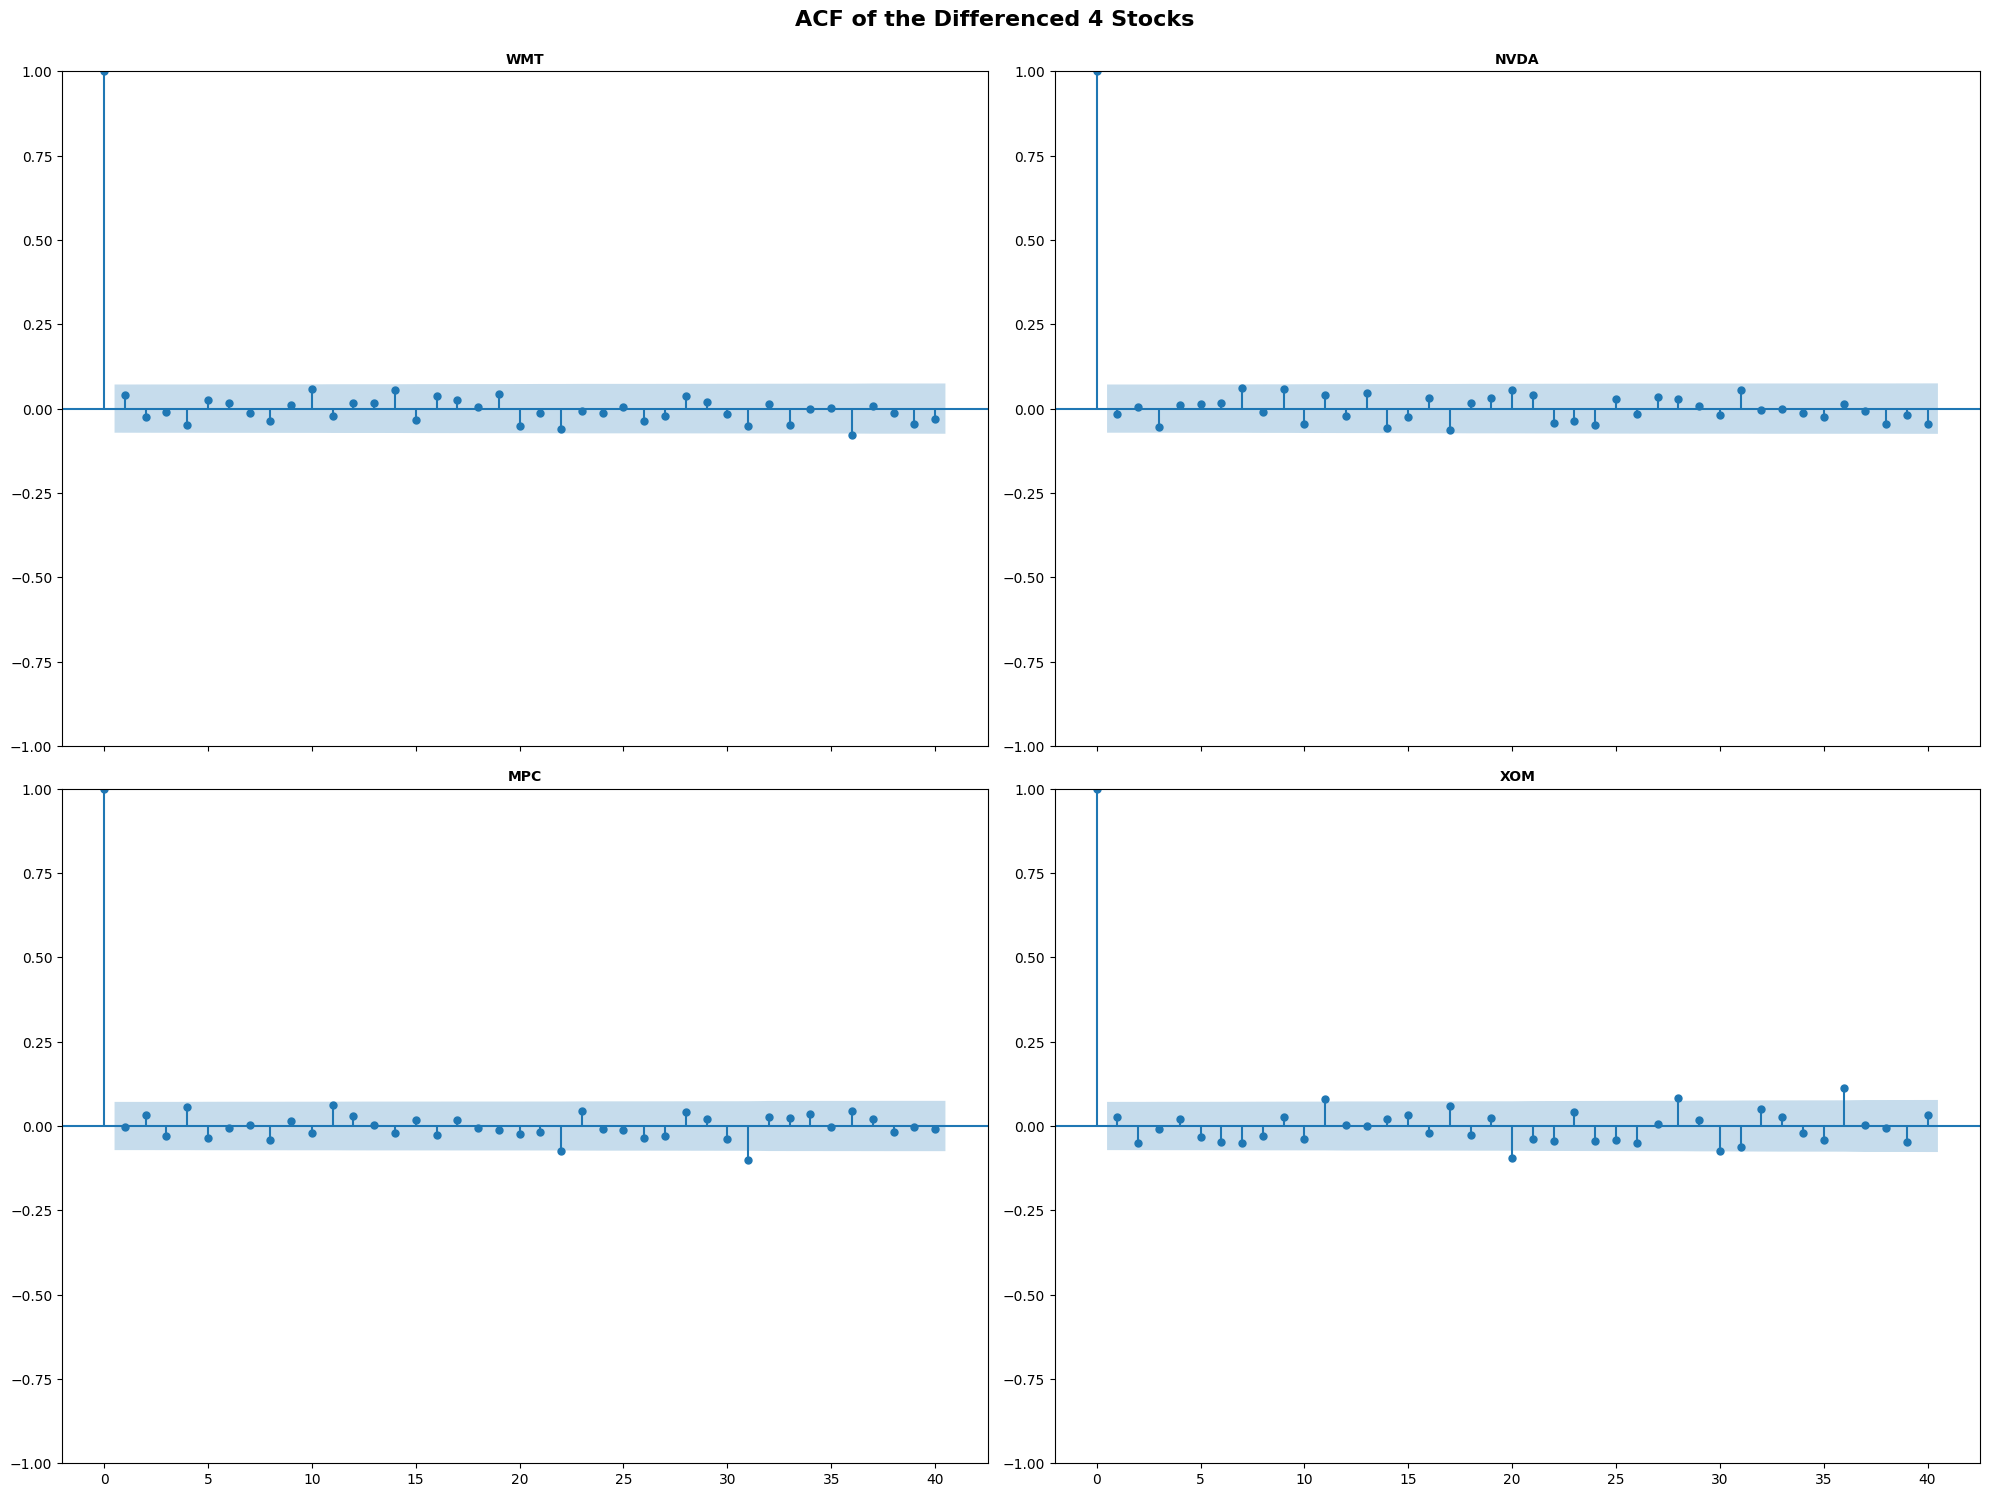

Figure: ACF of the differenced 4 Stocks


In [22]:
# Assuming close_log_df1 is your differenced data
fig, axs = plt.subplots(2, 2, figsize=(20, 15), sharex=True)

for ax, stock in zip(axs.flatten(), close_log_df1.columns):
    # Plot ACF
    plot_acf(close_log_df1[stock].dropna(), ax=ax, lags=40)
    ax.set_title(stock, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    #ax.set_ylim(-0.15, 0.15)

# Add main title
fig.suptitle('ACF of the Differenced 4 Stocks', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("Figure: ACF of the differenced 4 Stocks")

All of the stocks don't seem to show much autocorrelation after differencing, so

Optimal q = 0, except for BAC and MS where q = 1

 We can also use Bayesian Information Criterion (BIC) to help us confirm what is the most optimal (p,q) combination

In [56]:
close_log_df

Ticker,WMT,NVDA,MPC,XOM
Date,,,,
2022-01-03,3.825565,3.403343,4.093457,4.009607
2022-01-04,3.807075,3.375367,4.125677,4.046532
2022-01-05,3.820505,3.316081,4.131998,4.058892
2022-01-06,3.817722,3.336662,4.159603,4.082140
2022-01-07,3.827223,3.303064,4.170660,4.090304
...,...,...,...,...
2024-12-24,4.521663,4.942995,4.885902,4.631162
2024-12-26,4.522849,4.940924,4.886198,4.632007
2024-12-27,4.510596,4.919836,4.888264,4.631913


In [58]:
# Store results for all stocks
all_results = []

# Test different orders for each stock
for stock in close_log_df.columns:
    results = {}
    
    for p in range(0, 4):
        for q in range(0, 4):
            try:
                model = ARIMA(close_log_df[stock], order=(p, 1, q))
                fitted = model.fit()
                results[(p, q)] = fitted.bic
            except Exception as e:
                # Skip models that fail to converge
                continue
    
    # Check if any models succeeded
    if len(results) > 0:
        best_model = min(results, key=results.get)
        all_results.append({
            'Stock': stock,
            'Optimal p': best_model[0],
            'Optimal q': best_model[1],
            'BIC': results[best_model]
        })
    else:
        all_results.append({
            'Stock': stock,
            'Optimal p': None,
            'Optimal q': None,
            'BIC': None
        })




In [60]:
# Create and display DataFrame
bic_results_df = pd.DataFrame(all_results)
print("\nOptimal ARIMA Orders by BIC:")
bic_results_df



Optimal ARIMA Orders by BIC:


,Stock,Optimal p,Optimal q,BIC
0,WMT,0,0,-4377.634174
1,NVDA,0,0,-2924.492827
2,MPC,0,0,-3717.605079
3,XOM,0,0,-3972.429262


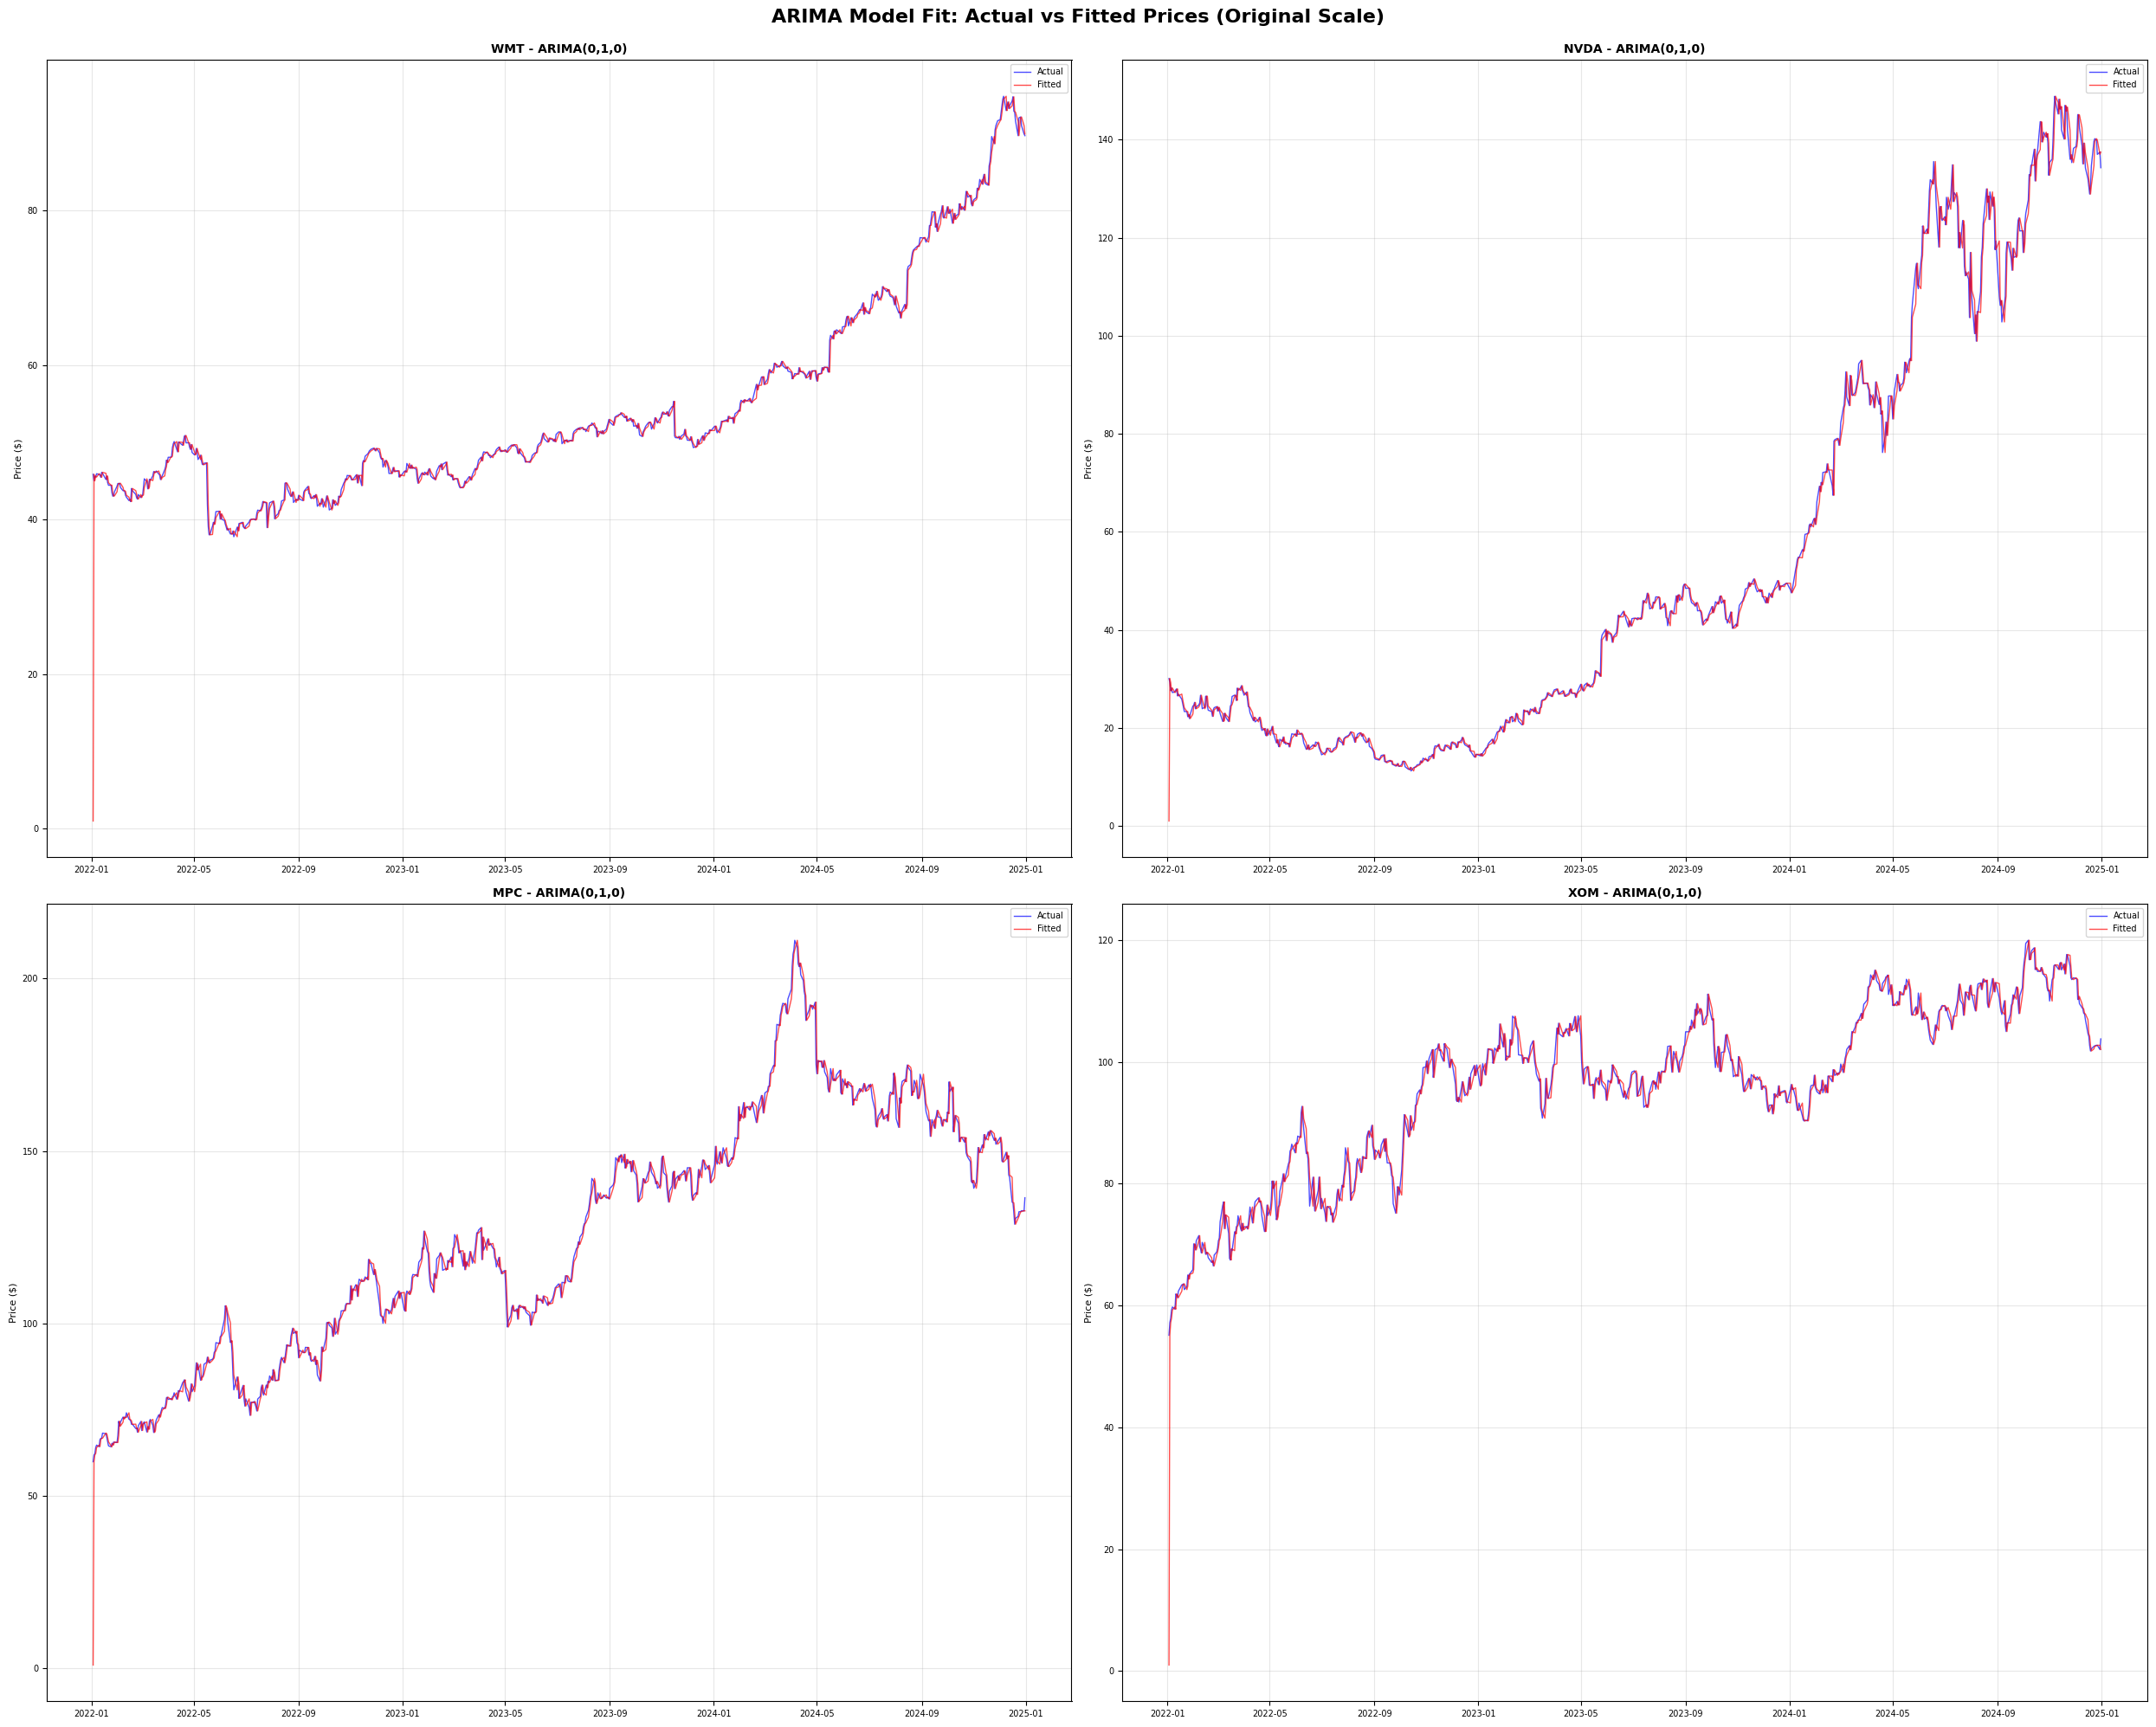

Figure: ARIMA model fitted values vs actual prices (non-differenced)


In [61]:
# Create subplots for all 30 stocks
fig, axs = plt.subplots(2, 2, figsize=(25, 20))

for ax, (_, row) in zip(axs.flatten(), bic_results_df.iterrows()):
    stock = row['Stock']
    p = int(row['Optimal p'])
    q = int(row['Optimal q'])
    
    try:
        # Get the original log prices (before differencing)
        original_data = close_historical_df[stock].dropna()
        log_data = np.log(original_data)
        
        # Fit ARIMA model with d=1 (since we need to difference)
        model = ARIMA(log_data, order=(p, 1, q))
        fitted_model = model.fit()
        
        # Get fitted values (in log scale)
        fitted_log = fitted_model.fittedvalues
        
        # Convert back to original price scale
        fitted_prices = np.exp(fitted_log)
        
        # Plot actual vs fitted in original price scale
        ax.plot(original_data.index, original_data.values, 
                label='Actual', color='blue', alpha=0.7, linewidth=1)
        ax.plot(fitted_prices.index, fitted_prices.values, 
                label='Fitted', color='red', alpha=0.7, linewidth=1)
        
        ax.set_title(f'{stock} - ARIMA({p},1,{q})', fontsize=10, fontweight='bold')
        ax.legend(fontsize=7, loc='best')
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', labelsize=7)
        ax.set_ylabel('Price ($)', fontsize=8)
        
    except Exception as e:
        ax.text(0.5, 0.5, f'{stock}\nModel failed\n{str(e)[:30]}', 
                ha='center', va='center', transform=ax.transAxes, fontsize=8)
        ax.set_title(f'{stock}', fontsize=10, fontweight='bold')

fig.suptitle('ARIMA Model Fit: Actual vs Fitted Prices (Original Scale)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("Figure: ARIMA model fitted values vs actual prices (non-differenced)")

In [62]:
def train_and_forecast_arima(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    bic_results_df: pd.DataFrame,
    horizon: int = None
) -> pd.DataFrame:
    """
    Train ARIMA(p,1,q) models using optimal p and q, then forecast the next horizon steps.
    """

    import warnings
    warnings.filterwarnings("ignore")

    if horizon is None:
        horizon = len(val_df)  # default to validation length

    # Ensure Stock is index
    bic_results_df = bic_results_df.set_index("Stock")

    # Prepare forecast container — same index as validation set
    arima_forecasts = pd.DataFrame(index=val_df.index, columns=val_df.columns)

    # Iterate through each stock
    for stock in train_df.columns:

        # Check if stock has BIC results
        if stock not in bic_results_df.index:
            print(f"Warning: No optimal orders found for {stock}. Skipping.")
            arima_forecasts[stock] = np.nan
            continue

        try:
            # Extract optimal p, q (ensure INT)
            p = int(bic_results_df.loc[stock, "Optimal p"])
            q = int(bic_results_df.loc[stock, "Optimal q"])
            order = (p, 1, q)

            # Fit ARIMA
            model = ARIMA(train_df[stock], order=order).fit()

            # Generate forecast
            forecast_obj = model.get_forecast(steps=horizon)
            forecast = forecast_obj.predicted_mean

            # Align forecast index to validation index
            forecast.index = val_df.index

            # Store
            arima_forecasts[stock] = forecast

        except Exception as e:
            print(f"Error fitting/forecasting ARIMA for {stock}: {e}")
            arima_forecasts[stock] = np.nan

    return arima_forecasts


In [63]:
bic_results_df

,Stock,Optimal p,Optimal q,BIC
0,WMT,0,0,-4377.634174
1,NVDA,0,0,-2924.492827
2,MPC,0,0,-3717.605079
3,XOM,0,0,-3972.429262


In [64]:
arima_forecasts_df = train_and_forecast_arima(
    train_df, 
    val_df, 
    bic_results_df, 
    horizon=val_df.shape[0]
)


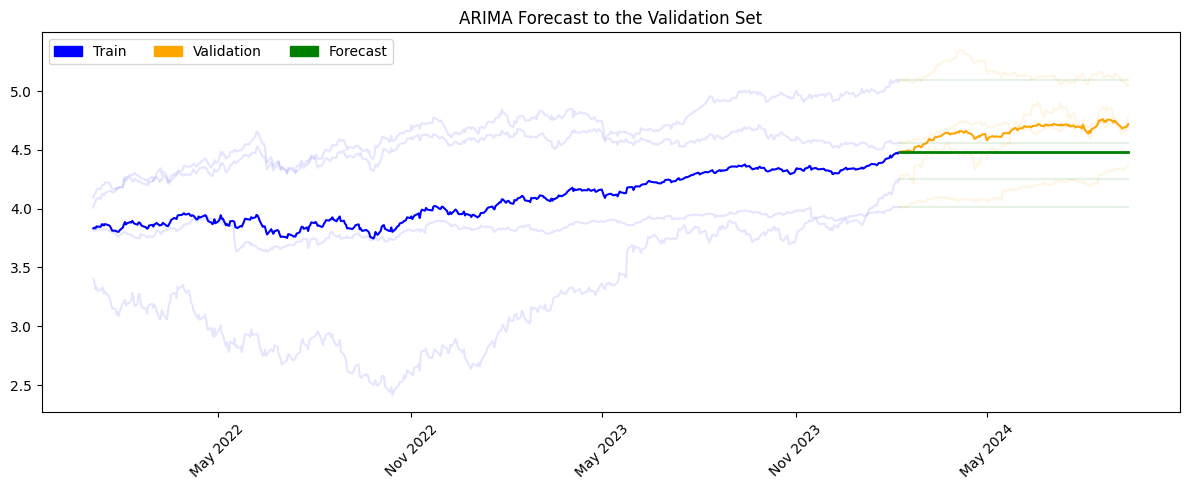

In [65]:
fig, ax = plt.subplots(figsize=(12, 5))

opacity_num = 0.1

# --- Training data ---
ax.plot(train_df, color='blue', alpha=opacity_num)
ax.plot(train_df.mean(axis=1), color='blue')

# --- Validation data ---
ax.plot(val_df, color='orange', alpha=opacity_num)
ax.plot(val_df.mean(axis=1), color='orange')

# --- ARIMA forecast ---
ax.plot(arima_forecasts_df, color='green', alpha=opacity_num, label='ARIMA Forecast')
ax.plot(arima_forecasts_df.mean(axis=1), color='green', linewidth=2, label='ARIMA Forecast Mean')

ax.set_title('ARIMA Forecast to the Validation Set')

# Prettier x-axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

# Add patches legend at the bottom for dataset colors
train_patch = mpatches.Patch(color='blue', label='Train')
val_patch = mpatches.Patch(color='orange', label='Validation')
forecast_patch = mpatches.Patch(color='green', label='Forecast')

plt.legend(handles=[train_patch, val_patch, forecast_patch], loc='best', ncol=3)

plt.show()

As expected, ARIMA performed similarly to Naive, because Stock price data perform similarly to a random walk.

# Random Walk with Drift

Let us now extend the random walk to add a drift.

In [68]:
# Example: train_df is log prices, columns = stocks, rows = dates
forecast_horizon = 150

# 1. Compute mean log return (drift) per stock
drift = train_df.diff().mean(axis=0)  # pandas Series, index = stocks

# 2. Get last log price per stock
last_log_price = train_df.iloc[-1]   # Series, index = stocks

# 3. Create random walk with drift
# For simplicity, here we just add the drift deterministically (no noise)
forecast_log_prices = pd.DataFrame(
    index=val_df.index, 
    columns=train_df.columns,
    dtype=float
)

for stock in train_df.columns:
    # Add drift cumulatively
    forecast_log_prices[stock] = last_log_price[stock] + np.cumsum(np.repeat(drift[stock], forecast_horizon))

# Get the performance
for stock in selected_stocks:
    performance_stock[stock]['Random Wak with Drift'] = ForecastingMetrics.compute_all_metrics(
        val_df[stock], forecast_log_prices[stock]
    )

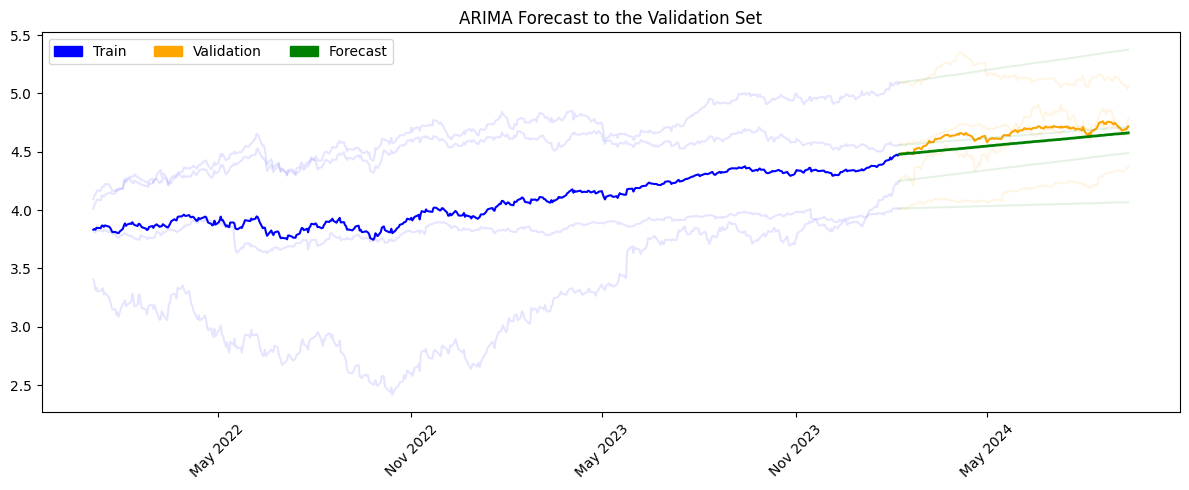

In [69]:
fig, ax = plt.subplots(figsize=(12, 5))

opacity_num = 0.1

# --- Training data ---
ax.plot(train_df, color='blue', alpha=opacity_num)
ax.plot(train_df.mean(axis=1), color='blue')

# --- Validation data ---
ax.plot(val_df, color='orange', alpha=opacity_num)
ax.plot(val_df.mean(axis=1), color='orange')

# --- ARIMA forecast ---
ax.plot(forecast_log_prices, color='green', alpha=opacity_num, label='ARIMA Forecast')
ax.plot(forecast_log_prices.mean(axis=1), color='green', linewidth=2, label='ARIMA Forecast Mean')

ax.set_title('ARIMA Forecast to the Validation Set')

# Prettier x-axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

# Add patches legend at the bottom for dataset colors
train_patch = mpatches.Patch(color='blue', label='Train')
val_patch = mpatches.Patch(color='orange', label='Validation')
forecast_patch = mpatches.Patch(color='green', label='Forecast')

plt.legend(handles=[train_patch, val_patch, forecast_patch], loc='best', ncol=3)

plt.show()

# Apply ML Models

Defining functions

In [70]:
# Selected stocks
selected_stocks = ['WMT', 'NVDA', 'MPC', 'XOM']

# --- Use the 70/20/10 split from Code 2 ---
# train_df, val_df, test_df are already defined
train_selected = train_df[selected_stocks]
val_selected = val_df[selected_stocks]

# Dictionaries to store forecasts
lr_forecasts = {}
rf_forecasts = {}
ridge_forecasts = {}
gb_forecasts = {}
xgb_forecasts = {}

# Train models and make forecasts
for stock in selected_stocks:
    X_train = np.arange(len(train_selected)).reshape(-1, 1)
    y_train = train_selected[stock].values
    X_val = np.arange(len(train_selected), len(train_selected) + len(val_selected)).reshape(-1, 1)
    
    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    lr_forecasts[stock] = lr.predict(X_val)
    
    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    rf_forecasts[stock] = rf.predict(X_val)
    
    # Ridge Regression
    ridge = Ridge()
    ridge.fit(X_train, y_train)
    ridge_forecasts[stock] = ridge.predict(X_val)
    
    # Gradient Boosting
    gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
    gb.fit(X_train, y_train)
    gb_forecasts[stock] = gb.predict(X_val)
    
    # XGBoost
    xg = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    xg.fit(X_train, y_train)
    xgb_forecasts[stock] = xg.predict(X_val)


In [72]:
# Convert forecasts to DataFrames
lr_forecasts_df = pd.DataFrame(lr_forecasts, index=val_selected.index)
rf_forecasts_df = pd.DataFrame(rf_forecasts, index=val_selected.index)
ridge_forecasts_df = pd.DataFrame(ridge_forecasts, index=val_selected.index)
gb_forecasts_df = pd.DataFrame(gb_forecasts, index=val_selected.index)
xgb_forecasts_df = pd.DataFrame(xgb_forecasts, index=val_selected.index)

# Append new model metrics to performance_stock
for stock in selected_stocks:
    performance_stock[stock]['Linear Regression'] = ForecastingMetrics.compute_all_metrics(
        val_selected[stock], lr_forecasts_df[stock]
    )
    performance_stock[stock]['Random Forest'] = ForecastingMetrics.compute_all_metrics(
        val_selected[stock], rf_forecasts_df[stock]
    )
    performance_stock[stock]['Ridge Regression'] = ForecastingMetrics.compute_all_metrics(
        val_selected[stock], ridge_forecasts_df[stock]
    )
    performance_stock[stock]['Gradient Boosting'] = ForecastingMetrics.compute_all_metrics(
        val_selected[stock], gb_forecasts_df[stock]
    )
    performance_stock[stock]['XGBoost'] = ForecastingMetrics.compute_all_metrics(
        val_selected[stock], xgb_forecasts_df[stock]
    )

# metrics_df_selected = performance_dict_to_df(performance_stock)

# # Display metrics per stock sorted by MSE (smallest to largest)
# for stock in selected_stocks:
#     print(f"Metrics for {stock} (sorted by MSE):")
#     stock_metrics = metrics_df_selected.loc[stock].sort_values(by='MSE')
#     display(stock_metrics)
#     print("-" * 60)

# Comparing it to methodology study of Ślusarczyk and Ślepaczuk 

In [73]:
pip install pandas numpy statsmodels arch tqdm

Note: you may need to restart the kernel to use updated packages.


In [74]:
# --- Use the currently defined variables ---
# train_df, val_df, test_df are already defined (70/20/10 split)
# Just assign log returns if needed (they are already log returns if close_log_df was used)
logret_train = train_df.copy()
logret_val = val_df.copy()
logret_test = test_df.copy()

print(f"Training set: {train_df.shape[0]} rows ({train_df.shape[0]/(train_df.shape[0]+val_df.shape[0]+test_df.shape[0]):.0%})")
print(f"Validation set: {val_df.shape[0]} rows ({val_df.shape[0]/(train_df.shape[0]+val_df.shape[0]+test_df.shape[0]):.0%})")
print(f"Test set: {test_df.shape[0]} rows ({test_df.shape[0]/(train_df.shape[0]+val_df.shape[0]+test_df.shape[0]):.0%})")


Training set: 527 rows (70%)
Validation set: 150 rows (20%)
Test set: 76 rows (10%)


In [75]:
# --- ARIMA / ARIMA-GARCH forecasting --- #
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import het_arch
from arch import arch_model

# Dictionaries to store forecasts and methods
arima_forecasts = {}
method_used = {}

Tf = len(val_df)  # forecast horizon = validation period

# Forecast loop per stock
for stock in selected_stocks:
    r = train_df[stock].dropna()
    
    if len(r) < 20:
        arima_forecasts[stock] = np.zeros(Tf)
        method_used[stock] = "Skipped (not enough data)"
        continue

    # ARCH test
    try:
        stat, pval, _, _ = het_arch(r, nlags=5)
    except:
        pval = 1.0

    # Forecast
    order_by_god = (2,1,1)
    if pval < 0.05:  # reject H0 → ARIMA only
        try:
            arima_res = ARIMA(r, order=order_by_god).fit()
            arima_forecasts[stock] = arima_res.get_forecast(Tf).predicted_mean.values
            method_used[stock] = "ARIMA"
        except:
            arima_forecasts[stock] = np.zeros(Tf)
            method_used[stock] = "ARIMA (failed)"
    else:  # H0 not rejected → try ARIMA-GARCH
        try:
            arima_res = ARIMA(r, order=order_by_god).fit()
            arima_mean = arima_res.get_forecast(Tf).predicted_mean.values

            garch_mod = arch_model(arima_res.resid, p=1, q=1, mean='Zero')
            garch_res = garch_mod.fit(disp="off")

            sim = garch_res.simulate(garch_res.params, nobs=Tf, repetitions=50)
            sim_resid = sim["data"]

            arima_forecasts[stock] = (arima_mean[:, None] + sim_resid).mean(axis=1)
            method_used[stock] = "ARIMA-GARCH"
        except:
            try:
                fallback = ARIMA(r, order=order_by_god).fit()
                arima_forecasts[stock] = fallback.get_forecast(Tf).predicted_mean.values
                method_used[stock] = "ARIMA (fallback)"
            except:
                arima_forecasts[stock] = np.zeros(Tf)
                method_used[stock] = "Failed"

# Convert forecasts to DataFrame
arima_forecasts_df = pd.DataFrame(arima_forecasts, index=val_df.index)

# Compute metrics and append to existing performance_stock
for stock in selected_stocks:
    performance_stock[stock]['ARIMA/ARIMA-GARCH'] = ForecastingMetrics.compute_all_metrics(
        val_df[stock], arima_forecasts_df[stock]
    )

# VAR

In [76]:
# ChatGPT made this dictionary
stock_categories = {
    "AAPL": "Technology", "MSFT": "Technology", "NVDA": "Technology",
    "AMZN": "Technology", "GOOGL": "Technology", "META": "Technology", "TSLA": "Technology",
    "JPM": "Finance", "BAC": "Finance", "WFC": "Finance", "C": "Finance", "GS": "Finance", "MS": "Finance",
    "KO": "Consumer Goods", "PG": "Consumer Goods", "PEP": "Consumer Goods",
    "WMT": "Consumer Goods", "COST": "Consumer Goods",
    "CL": "Consumer Goods", "XOM": "Energy", "CVX": "Energy", "COP": "Energy",
    "SLB": "Energy", "EOG": "Energy", "MPC": "Energy",
    "SPY": "ETF", "QQQ": "ETF", "DIA": "ETF", "IWM": "ETF", "VTI": "ETF"
}

# Get the inverse of stock_categories
category_stock = {}
for stock, category in stock_categories.items():
    if category not in category_stock:
        category_stock[category] = []
    category_stock[category].append(stock)

In [77]:
# Get again the dataframes for this
all_log_df = np.log(yf.download(stocks, start=start, end=end, auto_adjust=True)["Close"])
all_train_df = all_log_df.iloc[:train_end]

# we minus one because we will difference
all_val_df = all_log_df.iloc[train_end - 1:val_end]
all_test_df = all_log_df.iloc[val_end - 1:]


[*********************100%***********************]  30 of 30 completed


In [78]:
log_returns_train = all_train_df.diff().dropna()
log_returns_val = all_val_df.diff().dropna()

# Dictionaries to store forecasts
var_forecasts = {}
var_methods = {}

for stock in selected_stocks:
    # Find related stocks in the same category
    related_stocks = category_stock[stock_categories[stock]]

    # Select returns for training and validation
    related_returns_train = log_returns_train[related_stocks]
    related_returns_val = log_returns_val[related_stocks]

    # Fit VAR on related returns
    model = VAR(related_returns_train)
    lag_selection = model.select_order(maxlags=5)
    best_lag = lag_selection.selected_orders['aic']
    print(f"Selected lag order (AIC) for {stock}: {best_lag}")

    var_res = model.fit(best_lag)

    # Forecast returns for validation period
    if best_lag == 0:
        # Predict mean return for all steps
        mean_return = related_returns_train.mean()
        forecast_returns = np.tile(mean_return.values, (len(related_returns_val), 1))
    else:
        forecast_returns = var_res.forecast(
            related_returns_train.values[-best_lag:], 
            steps=len(related_returns_val)
        )

    forecast_returns_df = pd.DataFrame(
        forecast_returns,
        index=related_returns_val.index,
        columns=related_returns_train.columns
    )

    # Convert forecasted returns back to log prices
    last_log_price = all_train_df[stock].iloc[-1]
    adjusted_all_val_df = all_val_df.iloc[1:]
    forecast_log_price = last_log_price + np.cumsum(forecast_returns_df[stock])

    # Save forecast
    var_forecasts[stock] = forecast_log_price

    # Save **only the target stock** forecast
    var_forecasted = forecast_returns_df[stock]
    performance_stock[stock][f'VAR ({best_lag})'] = ForecastingMetrics.compute_all_metrics(
    adjusted_all_val_df[stock], forecast_log_price
)

Selected lag order (AIC) for WMT: 0
Selected lag order (AIC) for NVDA: 0
Selected lag order (AIC) for MPC: 1
Selected lag order (AIC) for XOM: 1


In [79]:
metrics_df_selected = performance_dict_to_df(performance_stock)

# Display metrics per stock sorted by MSE (smallest to largest)
for stock in selected_stocks:
    print(f"Metrics for {stock} (sorted by MSE):")
    stock_metrics = metrics_df_selected.loc[stock].sort_values(by='MSE')
    display(stock_metrics)
    print("-" * 60)

Metrics for WMT (sorted by MSE):


,MAE,MSE,RMSE,MAPE,SMAPE,Directional Accuracy
Model,,,,,,
Random Wak with Drift,0.118807,0.020245,0.142284,2.815797,2.873025,57.046978
VAR (0),0.118807,0.020245,0.142284,2.815797,2.873025,57.046978
Random Forest,0.145525,0.029810,0.172655,3.450502,3.535269,42.953022
Naive,0.145786,0.029891,0.172891,3.456762,3.541766,42.953022
ARIMA/ARIMA-GARCH,0.146032,0.029967,0.173110,3.462668,3.547894,46.308723
XGBoost,0.146359,0.030068,0.173401,3.470513,3.556033,42.953022
Linear Regression,0.158385,0.030730,0.175299,3.769462,3.857340,57.046978
Ridge Regression,0.158386,0.030730,0.175299,3.769463,3.857340,57.046978
Gradient Boosting,0.148900,0.030831,0.175588,3.531586,3.619334,42.953022


------------------------------------------------------------
Metrics for NVDA (sorted by MSE):


,MAE,MSE,RMSE,MAPE,SMAPE,Directional Accuracy
Model,,,,,,
Random Wak with Drift,0.244972,0.077186,0.277823,5.208630,5.385542,54.362415
VAR (0),0.244972,0.077186,0.277823,5.208630,5.385542,54.362415
ARIMA/ARIMA-GARCH,0.365603,0.167069,0.408741,7.775936,8.166260,44.295303
Naive,0.366027,0.167392,0.409136,7.785086,8.176199,45.637585
Random Forest,0.377424,0.176127,0.419675,8.031747,8.444197,45.637585
Gradient Boosting,0.384499,0.181586,0.426129,8.185113,8.610919,45.637585
XGBoost,0.389962,0.185872,0.431128,8.303539,8.739845,45.637585
Seasonal Naive,0.511087,0.297947,0.545845,10.938992,11.655951,47.651009
Linear Regression,0.577836,0.347626,0.589598,12.452667,13.306430,54.362415


------------------------------------------------------------
Metrics for MPC (sorted by MSE):


,MAE,MSE,RMSE,MAPE,SMAPE,Directional Accuracy
Model,,,,,,
Naive,0.066385,0.008824,0.093936,1.271640,1.287488,46.308723
ARIMA/ARIMA-GARCH,0.066638,0.008869,0.094176,1.276515,1.292456,50.335571
Random Forest,0.069757,0.009437,0.097145,1.336663,1.353757,46.308723
XGBoost,0.071610,0.009774,0.098864,1.372421,1.390186,46.308723
Gradient Boosting,0.073994,0.010206,0.101024,1.418469,1.437085,46.308723
Ridge Regression,0.099415,0.013643,0.116804,1.924588,1.920982,53.691277
Linear Regression,0.099415,0.013643,0.116804,1.924589,1.920982,53.691277
Seasonal Naive,0.123777,0.021508,0.146655,2.385126,2.425303,48.993290
VAR (1),0.126880,0.022232,0.149102,2.467901,2.437013,53.691277


------------------------------------------------------------
Metrics for XOM (sorted by MSE):


,MAE,MSE,RMSE,MAPE,SMAPE,Directional Accuracy
Model,,,,,,
Random Wak with Drift,0.049045,0.003953,0.062875,1.043502,1.052179,51.677853
VAR (1),0.051750,0.004213,0.064907,1.100911,1.110301,51.677853
Ridge Regression,0.068377,0.006068,0.077900,1.466740,1.452896,51.677853
Linear Regression,0.068377,0.006068,0.077900,1.466741,1.452897,51.677853
Naive,0.123646,0.017429,0.132018,2.631739,2.671726,48.322147
ARIMA/ARIMA-GARCH,0.123972,0.017512,0.132331,2.638692,2.678871,47.651009
Random Forest,0.124259,0.017585,0.132607,2.644816,2.685165,48.322147
Gradient Boosting,0.124829,0.017730,0.133155,2.656981,2.697667,48.322147
XGBoost,0.125324,0.017857,0.133631,2.667540,2.708521,48.322147


------------------------------------------------------------
